# Konfigurasi

In [5]:
from PIL import Image
import matplotlib.pyplot as plt

In [6]:
img1 = Image.open("/content/gmbr1.jpg").convert("RGB")
img2 = Image.open("/content/gmbr2.jpg").convert("RGB")
img3 = Image.open("/content/gmbr3.png").convert("RGB")

print("Gambar 1:", img1.size)
print("Gambar 2:", img2.size)
print("Gambar 3:", img3.size)

Gambar 1: (256, 256)
Gambar 2: (256, 256)
Gambar 3: (256, 256)


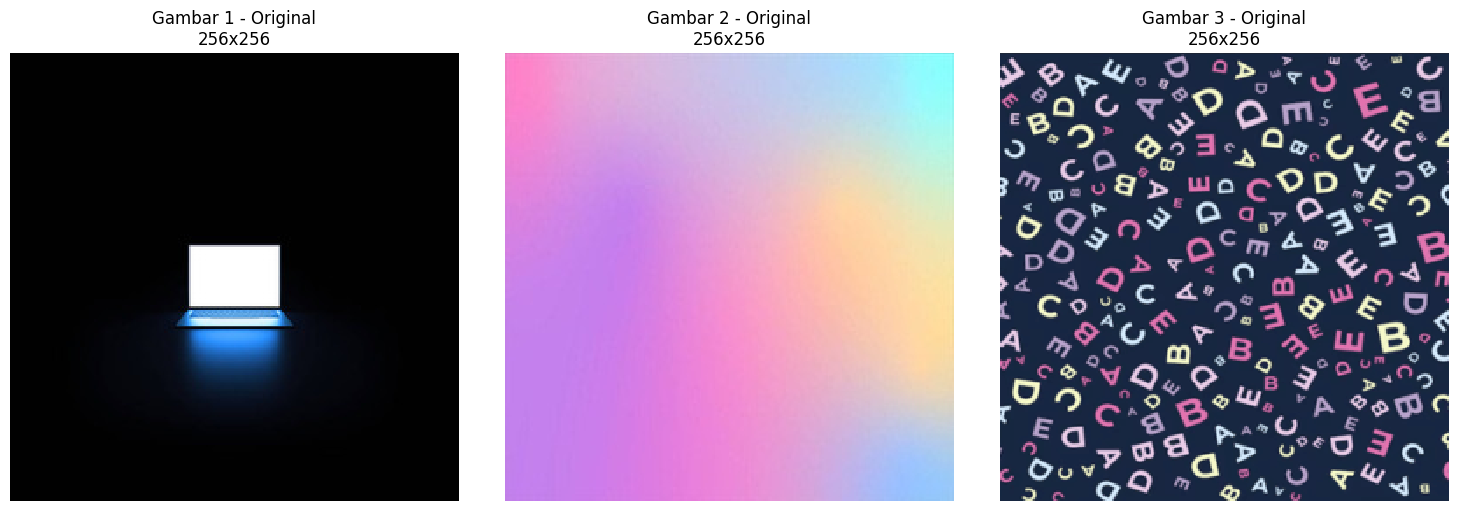

In [7]:
plt.figure(figsize=(15, 5))

# Gambar 1
plt.subplot(1, 3, 1)
plt.imshow(img1, interpolation="nearest")
plt.title(
    f"Gambar 1 - Original\n"
    f"{img1.size[0]}x{img1.size[1]}"
)
plt.axis("off")

# Gambar 2
plt.subplot(1, 3, 2)
plt.imshow(img2, interpolation="nearest")
plt.title(
    f"Gambar 2 - Original\n"
    f"{img2.size[0]}x{img2.size[1]}"
)
plt.axis("off")

# Gambar 3
plt.subplot(1, 3, 3)
plt.imshow(img3, interpolation="nearest")
plt.title(
    f"Gambar 3 - Original\n"
    f"{img3.size[0]}x{img3.size[1]}"
)
plt.axis("off")

plt.tight_layout()
plt.show()

# Down Sampling

## Max

In [8]:
def downsampling_max(gambar):

    lebar, tinggi = gambar.size

    lebar_baru = lebar // 2
    tinggi_baru = tinggi // 2

    hasil = Image.new("RGB", (lebar_baru, tinggi_baru))

    for y in range(tinggi_baru):
        for x in range(lebar_baru):

            # mengambil 4 pixel dari gambar asli
            p1 = gambar.getpixel((x * 2, y * 2))
            p2 = gambar.getpixel((x * 2 + 1, y * 2))
            p3 = gambar.getpixel((x * 2, y * 2 + 1))
            p4 = gambar.getpixel((x * 2 + 1, y * 2 + 1))

            # mencari nilai terbesar
            r = max(p1[0], p2[0], p3[0], p4[0])
            g = max(p1[1], p2[1], p3[1], p4[1])
            b = max(p1[2], p2[2], p3[2], p4[2])

            hasil.putpixel((x, y), (r, g, b))

    return hasil

## Average

In [9]:
def downsampling_average(gambar):

    lebar, tinggi = gambar.size

    lebar_baru = lebar // 2
    tinggi_baru = tinggi // 2

    hasil = Image.new("RGB", (lebar_baru, tinggi_baru))

    for y in range(tinggi_baru):
        for x in range(lebar_baru):

            # mengambil 4 pixel dari gambar asli
            p1 = gambar.getpixel((x * 2, y * 2))
            p2 = gambar.getpixel((x * 2 + 1, y * 2))
            p3 = gambar.getpixel((x * 2, y * 2 + 1))
            p4 = gambar.getpixel((x * 2 + 1, y * 2 + 1))

            # menghitung rata-rata
            r = (p1[0] + p2[0] + p3[0] + p4[0]) // 4
            g = (p1[1] + p2[1] + p3[1] + p4[1]) // 4
            b = (p1[2] + p2[2] + p3[2] + p4[2]) // 4

            hasil.putpixel((x, y), (r, g, b))

    return hasil

## Median

In [10]:
def cari_median(data): # untuk mencari median

    data = sorted(data)

    nilai_tengah1 = data[1]
    nilai_tengah2 = data[2]

    median = (nilai_tengah1 + nilai_tengah2) // 2

    return median

def downsampling_median(gambar):

    lebar, tinggi = gambar.size

    lebar_baru = lebar // 2
    tinggi_baru = tinggi // 2

    hasil = Image.new("RGB", (lebar_baru, tinggi_baru))

    for y in range(tinggi_baru):
        for x in range(lebar_baru):

            p1 = gambar.getpixel((x * 2, y * 2))
            p2 = gambar.getpixel((x * 2 + 1, y * 2))
            p3 = gambar.getpixel((x * 2, y * 2 + 1))
            p4 = gambar.getpixel((x * 2 + 1, y * 2 + 1))

            # mengambil nilai R
            data_r = [
                p1[0],
                p2[0],
                p3[0],
                p4[0]
            ]

            # mengambil nilai G
            data_g = [
                p1[1],
                p2[1],
                p3[1],
                p4[1]
            ]

            # mengambil nilai B
            data_b = [
                p1[2],
                p2[2],
                p3[2],
                p4[2]
            ]

            r = cari_median(data_r)
            g = cari_median(data_g)
            b = cari_median(data_b)

            hasil.putpixel((x, y), (r, g, b))

    return hasil

## Hasil Down Sampling

In [11]:
# Gambar 1
img1_max = downsampling_max(img1)
img1_average = downsampling_average(img1)
img1_median = downsampling_median(img1)

# Gambar 2
img2_max = downsampling_max(img2)
img2_average = downsampling_average(img2)
img2_median = downsampling_median(img2)

# Gambar 3
img3_max = downsampling_max(img3)
img3_average = downsampling_average(img3)
img3_median = downsampling_median(img3)

print("Original 1 :", img1.size)
print("Max        :", img1_max.size)
print("Average    :", img1_average.size)
print("Median     :", img1_median.size)

Original 1 : (256, 256)
Max        : (128, 128)
Average    : (128, 128)
Median     : (128, 128)


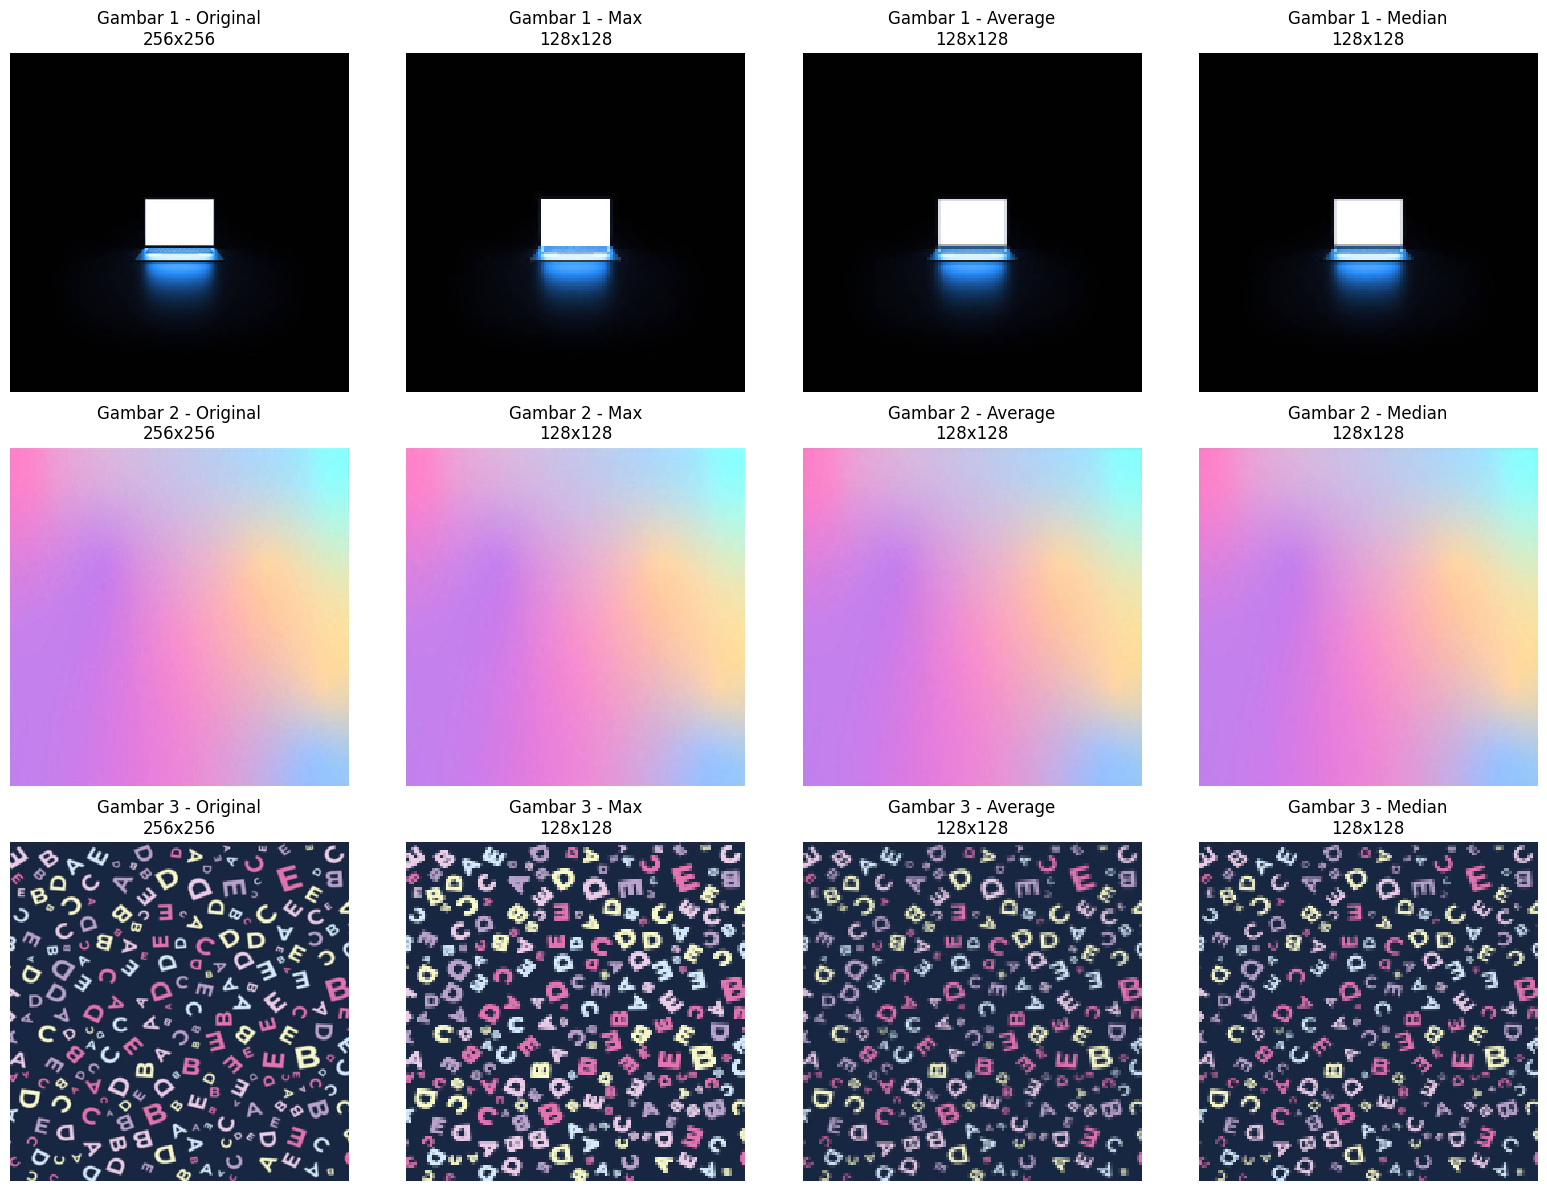

In [12]:
plt.figure(figsize=(16, 12))

# Gambar 1
plt.subplot(3, 4, 1)
plt.imshow(img1, interpolation="nearest")
plt.title(
    f"Gambar 1 - Original\n"
    f"{img1.size[0]}x{img1.size[1]}"
)
plt.axis("off")

plt.subplot(3, 4, 2)
plt.imshow(img1_max, interpolation="nearest")
plt.title(
    f"Gambar 1 - Max\n"
    f"{img1_max.size[0]}x{img1_max.size[1]}"
)
plt.axis("off")

plt.subplot(3, 4, 3)
plt.imshow(img1_average, interpolation="nearest")
plt.title(
    f"Gambar 1 - Average\n"
    f"{img1_average.size[0]}x{img1_average.size[1]}"
)
plt.axis("off")

plt.subplot(3, 4, 4)
plt.imshow(img1_median, interpolation="nearest")
plt.title(
    f"Gambar 1 - Median\n"
    f"{img1_median.size[0]}x{img1_median.size[1]}"
)
plt.axis("off")


# Gambar 2
plt.subplot(3, 4, 5)
plt.imshow(img2, interpolation="nearest")
plt.title(
    f"Gambar 2 - Original\n"
    f"{img2.size[0]}x{img2.size[1]}"
)
plt.axis("off")

plt.subplot(3, 4, 6)
plt.imshow(img2_max, interpolation="nearest")
plt.title(
    f"Gambar 2 - Max\n"
    f"{img2_max.size[0]}x{img2_max.size[1]}"
)
plt.axis("off")

plt.subplot(3, 4, 7)
plt.imshow(img2_average, interpolation="nearest")
plt.title(
    f"Gambar 2 - Average\n"
    f"{img2_average.size[0]}x{img2_average.size[1]}"
)
plt.axis("off")

plt.subplot(3, 4, 8)
plt.imshow(img2_median, interpolation="nearest")
plt.title(
    f"Gambar 2 - Median\n"
    f"{img2_median.size[0]}x{img2_median.size[1]}"
)
plt.axis("off")


# Gambar 3
plt.subplot(3, 4, 9)
plt.imshow(img3, interpolation="nearest")
plt.title(
    f"Gambar 3 - Original\n"
    f"{img3.size[0]}x{img3.size[1]}"
)
plt.axis("off")

plt.subplot(3, 4, 10)
plt.imshow(img3_max, interpolation="nearest")
plt.title(
    f"Gambar 3 - Max\n"
    f"{img3_max.size[0]}x{img3_max.size[1]}"
)
plt.axis("off")

plt.subplot(3, 4, 11)
plt.imshow(img3_average, interpolation="nearest")
plt.title(
    f"Gambar 3 - Average\n"
    f"{img3_average.size[0]}x{img3_average.size[1]}"
)
plt.axis("off")

plt.subplot(3, 4, 12)
plt.imshow(img3_median, interpolation="nearest")
plt.title(
    f"Gambar 3 - Median\n"
    f"{img3_median.size[0]}x{img3_median.size[1]}"
)
plt.axis("off")


plt.tight_layout()
plt.show()

# Up Sampling

## Nearest Neighbor

In [13]:
def upsampling_nn(gambar):

    lebar, tinggi = gambar.size

    lebar_baru = lebar * 2
    tinggi_baru = tinggi * 2

    hasil = Image.new("RGB", (lebar_baru, tinggi_baru))

    for y in range(tinggi_baru):
        for x in range(lebar_baru):

            x_asal = x // 2
            y_asal = y // 2

            pixel = gambar.getpixel((x_asal, y_asal))

            hasil.putpixel((x, y), pixel)

    return hasil

## Bilinear

In [14]:
def upsampling_bilinear(gambar):

    lebar, tinggi = gambar.size

    lebar_baru = lebar * 2
    tinggi_baru = tinggi * 2

    hasil = Image.new("RGB", (lebar_baru, tinggi_baru))

    for y in range(tinggi_baru):
        for x in range(lebar_baru):

            # mencari posisi pada gambar asli
            x_asal = x / 2
            y_asal = y / 2

            x1 = int(x_asal)
            y1 = int(y_asal)

            x2 = x1 + 1
            y2 = y1 + 1

            # supaya tidak keluar dari batas gambar
            if x2 >= lebar:
                x2 = lebar - 1

            if y2 >= tinggi:
                y2 = tinggi - 1

            dx = x_asal - x1
            dy = y_asal - y1

            # mengambil 4 pixel
            p1 = gambar.getpixel((x1, y1))
            p2 = gambar.getpixel((x2, y1))
            p3 = gambar.getpixel((x1, y2))
            p4 = gambar.getpixel((x2, y2))

            # channel merah
            r = int(
                p1[0] * (1 - dx) * (1 - dy)
                + p2[0] * dx * (1 - dy)
                + p3[0] * (1 - dx) * dy
                + p4[0] * dx * dy
            )

            # channel hijau
            g = int(
                p1[1] * (1 - dx) * (1 - dy)
                + p2[1] * dx * (1 - dy)
                + p3[1] * (1 - dx) * dy
                + p4[1] * dx * dy
            )

            # channel biru
            b = int(
                p1[2] * (1 - dx) * (1 - dy)
                + p2[2] * dx * (1 - dy)
                + p3[2] * (1 - dx) * dy
                + p4[2] * dx * dy
            )

            hasil.putpixel((x, y), (r, g, b))

    return hasil

## Bicubic

In [15]:
def cubic(x):

    x = abs(x)

    if x <= 1:

        hasil = (
            1.5 * x * x * x
            - 2.5 * x * x
            + 1
        )

    elif x < 2:

        hasil = (
            -0.5 * x * x * x
            + 2.5 * x * x
            - 4 * x
            + 2
        )

    else:

        hasil = 0

    return hasil

def upsampling_bicubic(gambar):

    lebar, tinggi = gambar.size

    lebar_baru = lebar * 2
    tinggi_baru = tinggi * 2

    hasil = Image.new("RGB", (lebar_baru, tinggi_baru))

    for y in range(tinggi_baru):
        for x in range(lebar_baru):

            x_asal = x / 2
            y_asal = y / 2

            x_dasar = int(x_asal)
            y_dasar = int(y_asal)

            total_r = 0
            total_g = 0
            total_b = 0

            total_bobot = 0

            # mengambil area 4 x 4 pixel
            for j in range(-1, 3):
                for i in range(-1, 3):

                    px = x_dasar + i
                    py = y_dasar + j

                    # menjaga supaya koordinat
                    # tidak keluar dari gambar

                    if px < 0:
                        px = 0

                    if py < 0:
                        py = 0

                    if px >= lebar:
                        px = lebar - 1

                    if py >= tinggi:
                        py = tinggi - 1

                    pixel = gambar.getpixel((px, py))

                    bobot_x = cubic(
                        x_asal - (x_dasar + i)
                    )

                    bobot_y = cubic(
                        y_asal - (y_dasar + j)
                    )

                    bobot = bobot_x * bobot_y

                    total_r += pixel[0] * bobot
                    total_g += pixel[1] * bobot
                    total_b += pixel[2] * bobot

                    total_bobot += bobot


            if total_bobot != 0:

                r = int(total_r / total_bobot)
                g = int(total_g / total_bobot)
                b = int(total_b / total_bobot)

            else:

                r = 0
                g = 0
                b = 0


            # nilai RGB harus berada antara 0 - 255

            if r < 0:
                r = 0
            elif r > 255:
                r = 255

            if g < 0:
                g = 0
            elif g > 255:
                g = 255

            if b < 0:
                b = 0
            elif b > 255:
                b = 255


            hasil.putpixel((x, y), (r, g, b))

    return hasil

## Hasil Up Sampling

In [16]:
# Gambar 1
img1_nn = upsampling_nn(img1)
img1_bilinear = upsampling_bilinear(img1)
img1_bicubic = upsampling_bicubic(img1)

# Gambar 2
img2_nn = upsampling_nn(img2)
img2_bilinear = upsampling_bilinear(img2)
img2_bicubic = upsampling_bicubic(img2)

# Gambar 3
img3_nn = upsampling_nn(img3)
img3_bilinear = upsampling_bilinear(img3)
img3_bicubic = upsampling_bicubic(img3)

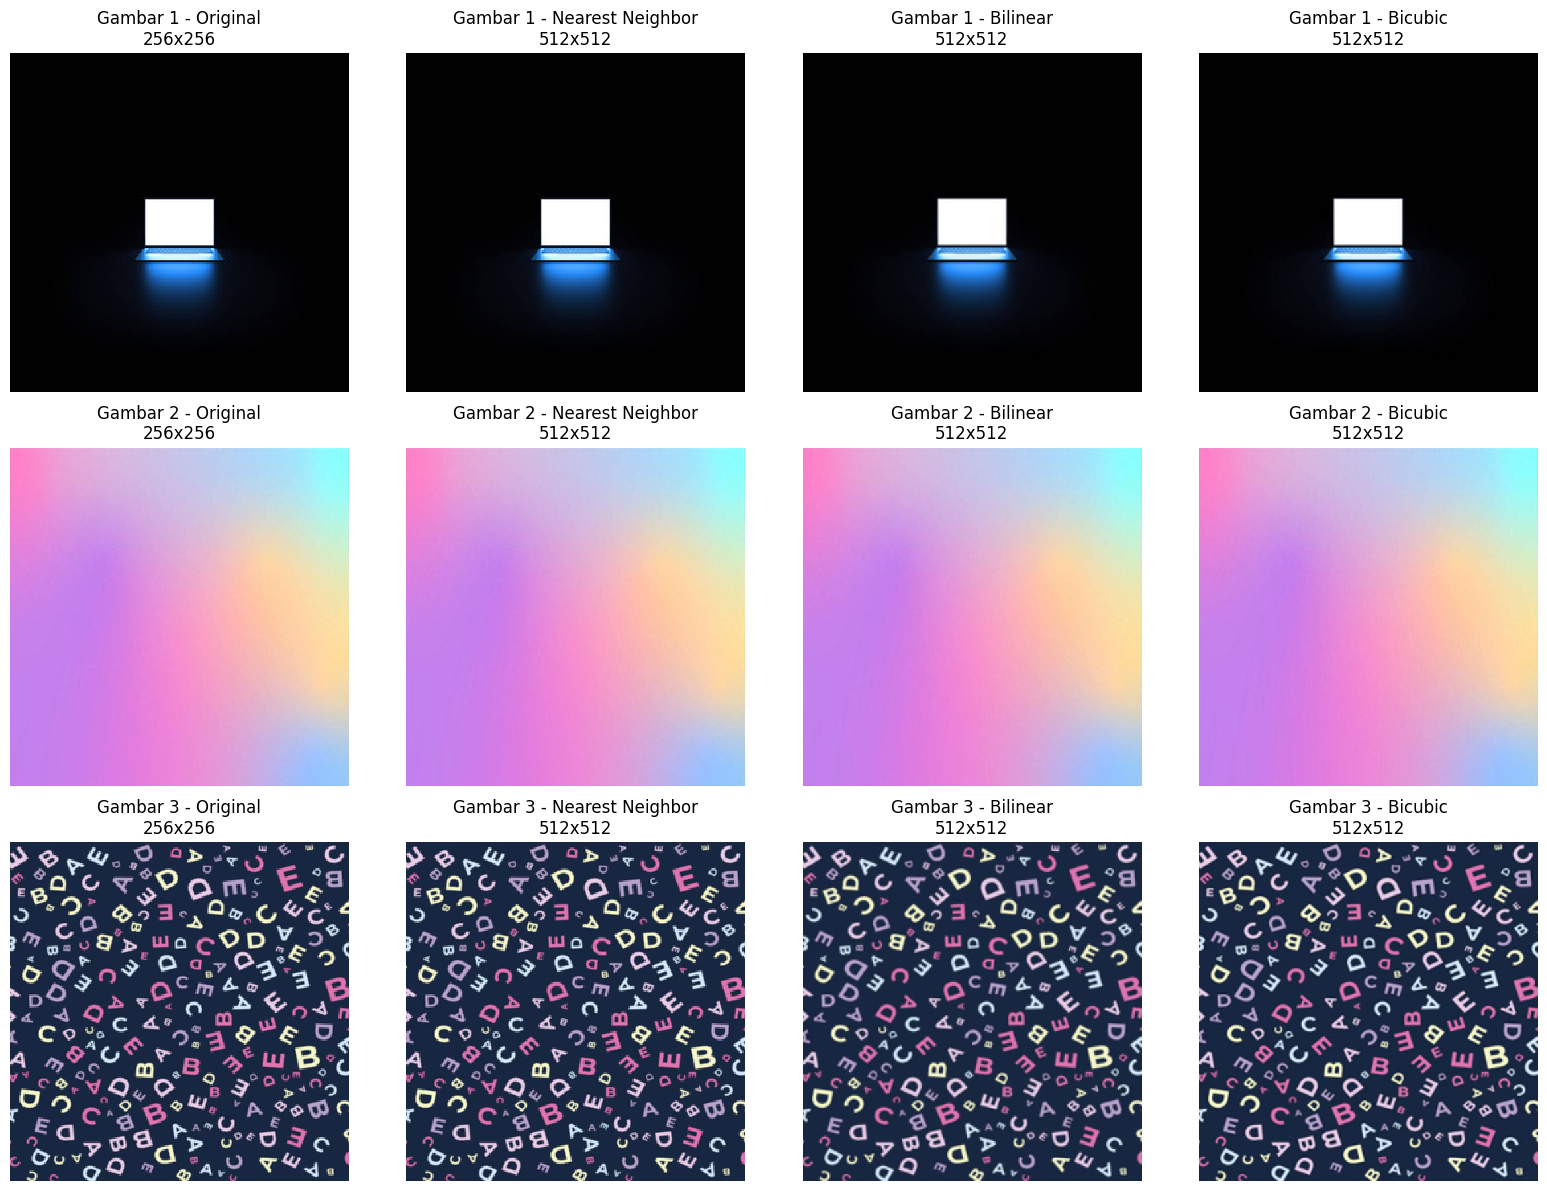

In [17]:
plt.figure(figsize=(16, 12))

# Gambar 1
plt.subplot(3, 4, 1)
plt.imshow(img1, interpolation="nearest")
plt.title(
    f"Gambar 1 - Original\n"
    f"{img1.size[0]}x{img1.size[1]}"
)
plt.axis("off")

plt.subplot(3, 4, 2)
plt.imshow(img1_nn, interpolation="nearest")
plt.title(
    f"Gambar 1 - Nearest Neighbor\n"
    f"{img1_nn.size[0]}x{img1_nn.size[1]}"
)
plt.axis("off")

plt.subplot(3, 4, 3)
plt.imshow(img1_bilinear, interpolation="nearest")
plt.title(
    f"Gambar 1 - Bilinear\n"
    f"{img1_bilinear.size[0]}x{img1_bilinear.size[1]}"
)
plt.axis("off")

plt.subplot(3, 4, 4)
plt.imshow(img1_bicubic, interpolation="nearest")
plt.title(
    f"Gambar 1 - Bicubic\n"
    f"{img1_bicubic.size[0]}x{img1_bicubic.size[1]}"
)
plt.axis("off")


# Gambar 2
plt.subplot(3, 4, 5)
plt.imshow(img2, interpolation="nearest")
plt.title(
    f"Gambar 2 - Original\n"
    f"{img2.size[0]}x{img2.size[1]}"
)
plt.axis("off")

plt.subplot(3, 4, 6)
plt.imshow(img2_nn, interpolation="nearest")
plt.title(
    f"Gambar 2 - Nearest Neighbor\n"
    f"{img2_nn.size[0]}x{img2_nn.size[1]}"
)
plt.axis("off")

plt.subplot(3, 4, 7)
plt.imshow(img2_bilinear, interpolation="nearest")
plt.title(
    f"Gambar 2 - Bilinear\n"
    f"{img2_bilinear.size[0]}x{img2_bilinear.size[1]}"
)
plt.axis("off")

plt.subplot(3, 4, 8)
plt.imshow(img2_bicubic, interpolation="nearest")
plt.title(
    f"Gambar 2 - Bicubic\n"
    f"{img2_bicubic.size[0]}x{img2_bicubic.size[1]}"
)
plt.axis("off")


# Gambar 3
plt.subplot(3, 4, 9)
plt.imshow(img3, interpolation="nearest")
plt.title(
    f"Gambar 3 - Original\n"
    f"{img3.size[0]}x{img3.size[1]}"
)
plt.axis("off")

plt.subplot(3, 4, 10)
plt.imshow(img3_nn, interpolation="nearest")
plt.title(
    f"Gambar 3 - Nearest Neighbor\n"
    f"{img3_nn.size[0]}x{img3_nn.size[1]}"
)
plt.axis("off")

plt.subplot(3, 4, 11)
plt.imshow(img3_bilinear, interpolation="nearest")
plt.title(
    f"Gambar 3 - Bilinear\n"
    f"{img3_bilinear.size[0]}x{img3_bilinear.size[1]}"
)
plt.axis("off")

plt.subplot(3, 4, 12)
plt.imshow(img3_bicubic, interpolation="nearest")
plt.title(
    f"Gambar 3 - Bicubic\n"
    f"{img3_bicubic.size[0]}x{img3_bicubic.size[1]}"
)
plt.axis("off")


plt.tight_layout()
plt.show()